<a href="https://colab.research.google.com/github/anand57577-lab/Garbage_Classification_CNN_Model/blob/main/DL_Garbage_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip Garbage_dataset.zip

Archive:  Garbage_dataset.zip
  inflating: dataset-resized/cardboard/cardboard1.jpg  
  inflating: dataset-resized/cardboard/cardboard10.jpg  
  inflating: dataset-resized/cardboard/cardboard100.jpg  
  inflating: dataset-resized/cardboard/cardboard101.jpg  
  inflating: dataset-resized/cardboard/cardboard102.jpg  
  inflating: dataset-resized/cardboard/cardboard103.jpg  
  inflating: dataset-resized/cardboard/cardboard104.jpg  
  inflating: dataset-resized/cardboard/cardboard105.jpg  
  inflating: dataset-resized/cardboard/cardboard106.jpg  
  inflating: dataset-resized/cardboard/cardboard107.jpg  
  inflating: dataset-resized/cardboard/cardboard108.jpg  
  inflating: dataset-resized/cardboard/cardboard109.jpg  
  inflating: dataset-resized/cardboard/cardboard11.jpg  
  inflating: dataset-resized/cardboard/cardboard110.jpg  
  inflating: dataset-resized/cardboard/cardboard111.jpg  
  inflating: dataset-resized/cardboard/cardboard112.jpg  
  inflating: dataset-resized/cardboard/cardboa

In [44]:
import tensorflow
import matplotlib.pyplot as plt
import numpy as np
import os


In [45]:
training_data = tensorflow.keras.utils.image_dataset_from_directory(
    'Garbage_data',
    validation_split = 0.2,
    subset = 'training',
    seed = 42,
    image_size = (224, 224),
    batch_size = 32
)

validation_data = tensorflow.keras.utils.image_dataset_from_directory(
    'Garbage_data',
    validation_split = 0.2,
    subset = 'validation',
    seed = 42,
    image_size  = (224,224),
    batch_size = 32
)


Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [46]:
class_names = training_data.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


**Visualization**

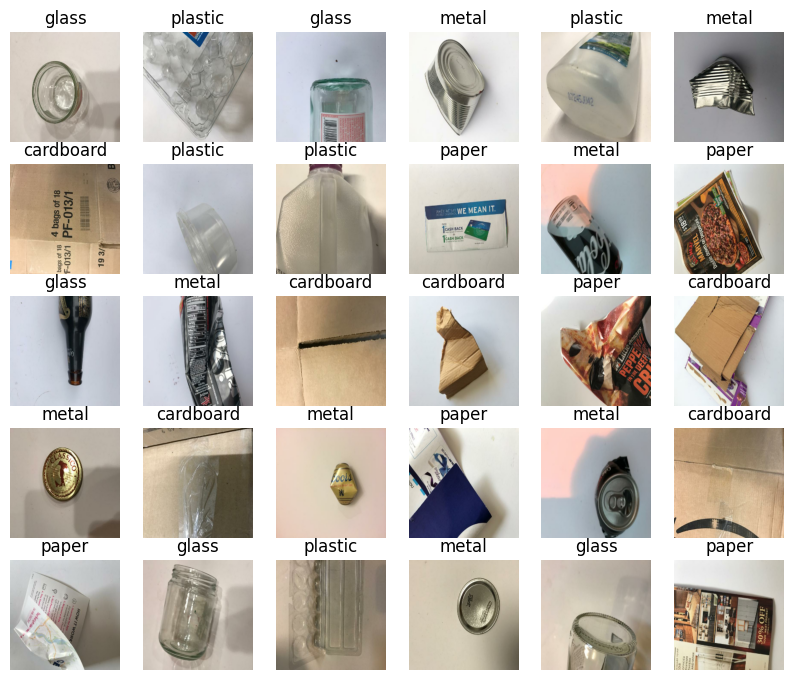

In [47]:
plt.figure(figsize = (10,10))

for images, label in training_data.take(1):
  for i in range(30):
    ax = plt.subplot(6,6 ,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(class_names[label[i]])
    plt.axis('off')

**Normailize the image**

In [48]:
normalization = tensorflow.keras.layers.Rescaling(1./255)

In [49]:
training_data = training_data.map(lambda x,y : (normalization(x), y))
validation_data  = validation_data.map(lambda x,y : (normalization(x),y))

**optimizing Data (cache() & prefetch())**

In [50]:
AUTOTUNE = tensorflow.data.AUTOTUNE

training_data = training_data.cache().prefetch(buffer_size = AUTOTUNE)
validation_data = validation_data.cache().prefetch(buffer_size = AUTOTUNE)


In [51]:
for images, labels in training_data.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense, Dropout, Flatten, Conv2D, MaxPooling2D

**CNN MODEL**

In [77]:
import tensorflow as tf

In [78]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [79]:
model  = Sequential()

In [80]:
model.add(Input(shape = (224,224,3)))
model.add(data_augmentation)
model.add(Conv2D(
    filters = 32,
    kernel_size = (3,3),
    activation = 'relu',
))

model.add(MaxPooling2D(pool_size  = (2,2)))

model.add(Conv2D(
    filters = 64,
    kernel_size = (3,3),
    activation  ='relu'
))

model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Conv2D(
    filters = 128,
    kernel_size = (3,3),
    activation = 'relu'
))

model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Conv2D(
    filters = 256,
    kernel_size = (3,3),
    activation = 'relu'
))

model.add(MaxPooling2D(pool_size = (2,2)))


model.add(Flatten())

model.add(Dense(
    128,
    activation = 'relu'
))

model.add(Dropout(0.5))

model.add(Dense(
    64,
    activation = 'relu'
))

model.add(Dropout(0.5))

model.add(Dense(
    6,
    activation = 'softmax'
))

In [81]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)


In [82]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,115,782 (19.52 MB)

 Trainable params: 5,115,782 (19.52 MB)

 Non-trainable params: 0 (0.00 B)

In [83]:
history = model.fit(training_data, validation_data= validation_data, epochs = 30)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.2038 - loss: 1.7715 - val_accuracy: 0.2673 - val_loss: 1.7349
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.2616 - loss: 1.6722 - val_accuracy: 0.1980 - val_loss: 1.6904
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.2859 - loss: 1.6385 - val_accuracy: 0.3525 - val_loss: 1.5549
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.3076 - loss: 1.5822 - val_accuracy: 0.3465 - val_loss: 1.5582
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.3526 - loss: 1.5132 - val_accuracy: 0.3802 - val_loss: 1.4292
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.4001 - loss: 1.4467 - val_accuracy: 0.3921 - val_loss: 1.4871
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.4070 - loss: 1.4293 - val_accuracy: 0.4257 - val_loss: 1.3628
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.4308 - loss: 1.3933 - val_accuracy: 0.4574 - 

In [84]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


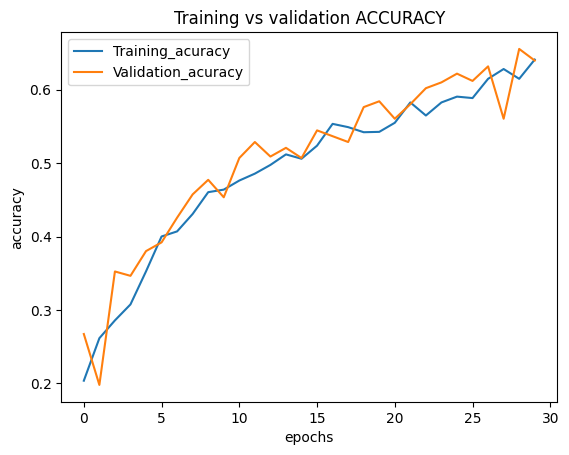

In [85]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label = 'Training_acuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation_acuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Training vs validation ACCURACY')
plt.legend()
plt.show()


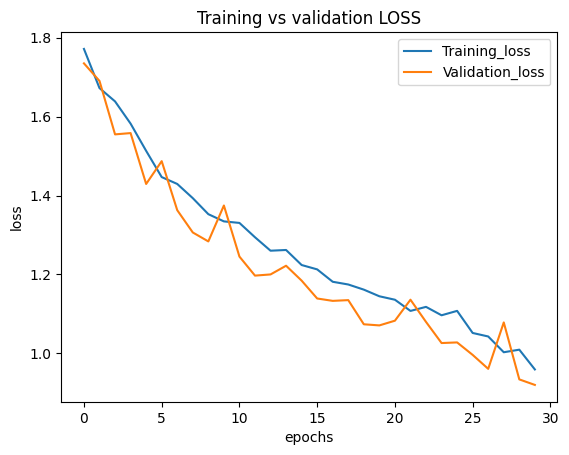

In [86]:
plt.plot(history.history['loss'], label = 'Training_loss')
plt.plot(history.history['val_loss'], label = 'Validation_loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Training vs validation LOSS')
plt.legend()
plt.show()

In [87]:
loss, accuracy = model.evaluate(validation_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6396 - loss: 0.9199


In [88]:
print(loss)
print(accuracy)


0.9198532104492188
0.6396039724349976


In [90]:
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

print(history.history['loss'][-1])
print(history.history['val_loss'][-1])

0.640949547290802
0.6396039724349976
0.9590981602668762
0.9198532104492188


In [91]:
prediction = model.predict(validation_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


Actual Class     : paper
Predicted Class  : paper
Prediction Score : [5.3223129e-03 1.8899969e-05 2.1139352e-02 9.7332203e-01 2.4680296e-05
 1.7283051e-04]


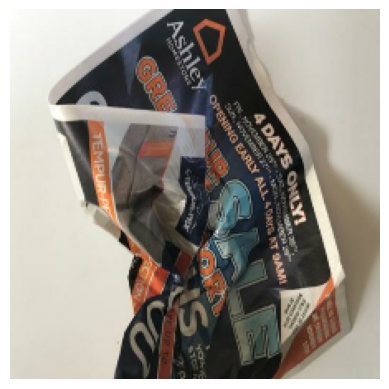

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# Get one batch from validation dataset
for images, labels in validation_data.take(1):

    # Select the first image
    image = images[2]
    actual_label = labels[2].numpy()

    # Predict
    prediction = model.predict(np.expand_dims(image, axis=0), verbose=0)

    predicted_label = np.argmax(prediction)

    # Display image
    plt.imshow(image.numpy())
    plt.axis("off")

    print("Actual Class     :", class_names[actual_label])
    print("Predicted Class  :", class_names[predicted_label])
    print("Prediction Score :", prediction[0])